# BSM Coincidence Histogram at Zero HOM Delay

This notebook runs one BSM-only HOM simulation at zero relative delay and plots the BSM1-BSM2 timestamp-difference histogram.

Operationally this uses only BSM-side detector streams: `BSM1_ps` and `BSM2_ps`. Idlers are not projected or detected because `herald_mode='bsm_only'`.

The histogram is useful for AI diagnostics because it exposes the observable coincidence peak/structure at the BSM without using fourfold information.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from example.hom_swapping_validation.simulator import (
    CoincidenceConfig,
    SequenceHOMConfig,
    run_hom_sequence_delay_scan,
)

plt.rcParams['figure.figsize'] = (8, 4)
pd.set_option('display.max_columns', 80)

## Simulation Settings

`SIM_DURATION_S = 1.0` means one physical second of source operation. With an 80 MHz source this schedules 80 million pulses, so it can take time. For a quick local check, reduce it to `0.01` or `0.05`.

In [16]:
SIM_DURATION_S = 1.0
SOURCE_FREQUENCY_HZ = 80_000_000.0
PULSES = int(round(SIM_DURATION_S * SOURCE_FREQUENCY_HZ))

cfg = SequenceHOMConfig(
    pulses_per_delay=PULSES,
    emission_chunk_pulses=25_000,
    source_frequency_hz=SOURCE_FREQUENCY_HZ,
    mean_photon_num=0.01,
    source_bandwidth_nm=0.1,
    wavelengths_nm_a=(1550.0, 1550.0),
    wavelengths_nm_b=(1550.0, 1550.0),
    photon_statistics='thermal',
    use_sparse_emission=True,
    source_bell_state_a='psi-',
    source_bell_state_b='psi-',
    arm_length_m_a=20_000.0,
    arm_length_m_b=20_000.0,
    herald_length_m_a=1.0,
    herald_length_m_b=1.0,
    attenuation_db_per_m=0.0002,
    detector_eff_bsm=1.0,
    detector_eff_herald=1.0,
    detector_jitter_ps=0.0,
    detector_dark_hz_bsm=0.0,
    detector_dark_hz_herald=0.0,
    hom_match_window_ps=1200,
    hom_coinc_window_ps=120,
    herald_mode='bsm_only',
    extra_overlap_scale=1.0,
    seed=42,
)

bsm_cfg = CoincidenceConfig(window_ps=120, offset_ps=0)
print(f'Simulating {SIM_DURATION_S:.3g} s = {PULSES:,} pulses at zero delay')

Simulating 1 s = 80,000,000 pulses at zero delay


In [17]:
df, streams = run_hom_sequence_delay_scan(
    delays_ps=[0],
    cfg=cfg,
    bsm_cfg=bsm_cfg,
    store_streams=True,
)

df

,delay_ps,bsm1_count,bsm2_count,bsm_twofold_count,bsm_twofold_rate_per_pulse,fiber_dcd_a_ps_per_nm_km,fiber_dcd_b_ps_per_nm_km,raman_noise_rate_total_hz,herald_mode
0,0,318292,318478,1511,0.000019,13.703052,13.703052,0.0,bsm_only


In [18]:
bsm1 = np.asarray(streams[0]['BSM1_ps'], dtype=np.int64)
bsm2 = np.asarray(streams[0]['BSM2_ps'], dtype=np.int64)

print('BSM1 clicks:', len(bsm1))
print('BSM2 clicks:', len(bsm2))
print('BSM twofolds inside configured window:', int(df['bsm_twofold_count'].iloc[0]))

BSM1 clicks: 318292
BSM2 clicks: 318478
BSM twofolds inside configured window: 1511


## Build BSM1-BSM2 Lag Histogram

For each BSM1 timestamp, we collect BSM2 timestamps within `HIST_RANGE_PS` and histogram the lag

```text
lag = t_BSM2 - t_BSM1
```

A peak near zero means the two BSM detectors have temporally correlated clicks. This is not a fourfold measurement and does not reveal idler projections.

In [19]:
HIST_RANGE_PS = 5_000
BIN_WIDTH_PS = 20

def bsm_lag_deltas_ps(t1_ps, t2_ps, hist_range_ps):
    t1 = np.asarray(t1_ps, dtype=np.int64)
    t2 = np.asarray(t2_ps, dtype=np.int64)
    deltas = []
    j0 = 0
    for t in t1:
        while j0 < len(t2) and t2[j0] < t - hist_range_ps:
            j0 += 1
        j = j0
        while j < len(t2) and t2[j] <= t + hist_range_ps:
            deltas.append(int(t2[j] - t))
            j += 1
    return np.asarray(deltas, dtype=np.int64)

deltas = bsm_lag_deltas_ps(bsm1, bsm2, HIST_RANGE_PS)

bins = np.arange(-HIST_RANGE_PS, HIST_RANGE_PS + BIN_WIDTH_PS, BIN_WIDTH_PS)
hist, edges = np.histogram(deltas, bins=bins)
centers = 0.5 * (edges[:-1] + edges[1:])

peak_idx = int(np.argmax(hist)) if len(hist) else 0
peak_position_ps = float(centers[peak_idx]) if len(hist) else 0.0
peak_height = int(hist[peak_idx]) if len(hist) else 0
coinc_mask = np.abs(centers) <= bsm_cfg.window_ps
coinc_count_from_hist = int(hist[coinc_mask].sum())

print('lag samples in histogram:', len(deltas))
print('histogram peak position ps:', peak_position_ps)
print('histogram peak height:', peak_height)
print('histogram counts within +/- BSM window:', coinc_count_from_hist)

lag samples in histogram: 1523
histogram peak position ps: 10.0
histogram peak height: 824
histogram counts within +/- BSM window: 1523


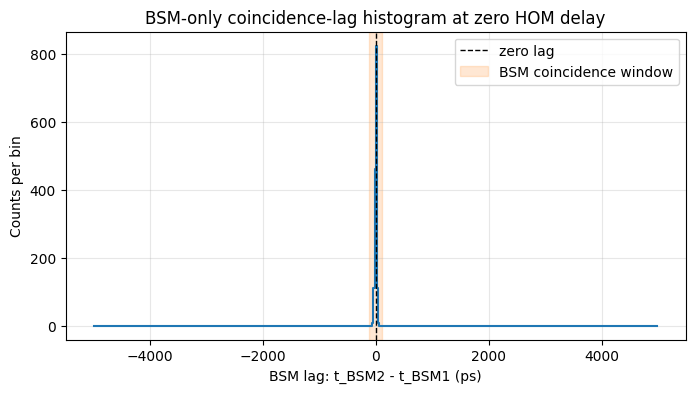

In [20]:
fig, ax = plt.subplots()
ax.step(centers, hist, where='mid', lw=1.5)
ax.axvline(0, color='black', linestyle='--', lw=1, label='zero lag')
ax.axvspan(-bsm_cfg.window_ps, bsm_cfg.window_ps, color='tab:orange', alpha=0.18, label='BSM coincidence window')
ax.set_xlabel('BSM lag: t_BSM2 - t_BSM1 (ps)')
ax.set_ylabel('Counts per bin')
ax.set_title('BSM-only coincidence-lag histogram at zero HOM delay')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

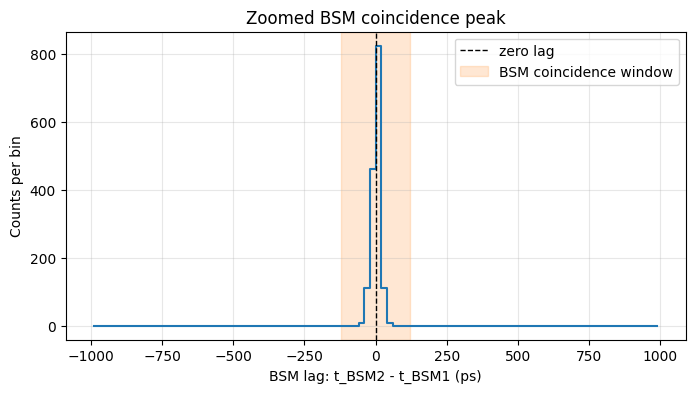

In [21]:
# Zoom around the BSM coincidence window.
zoom_mask = np.abs(centers) <= 1_000

fig, ax = plt.subplots()
ax.step(centers[zoom_mask], hist[zoom_mask], where='mid', lw=1.5)
ax.axvline(0, color='black', linestyle='--', lw=1, label='zero lag')
ax.axvspan(-bsm_cfg.window_ps, bsm_cfg.window_ps, color='tab:orange', alpha=0.18, label='BSM coincidence window')
ax.set_xlabel('BSM lag: t_BSM2 - t_BSM1 (ps)')
ax.set_ylabel('Counts per bin')
ax.set_title('Zoomed BSM coincidence peak')
ax.legend()
ax.grid(True, alpha=0.3)
plt.show()

## Interpretation

- `BSM1` and `BSM2` singles are the raw detector clicks at the BSM.
- The histogram shows whether `BSM2` clicks appear near `BSM1` clicks at a consistent lag.
- The orange region is the coincidence window used to count BSM twofolds.
- In BSM-only mode this is an operationally available feature. It does not use idlers, fourfolds, pair IDs, or simulator overlap truth.

For AI diagnostics, features such as peak position, peak width, peak height, background level, CAR, and drift over time can be extracted from this histogram.